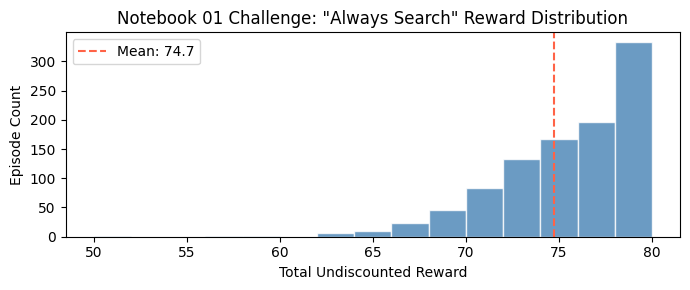

In [1]:
#MDP Formulation Challenge
import numpy as np
import matplotlib.pyplot as plt

alpha, beta = 0.9, 0.4
r_search_high, r_search_low = 4.0, 2.0
T = np.zeros((2, 3, 2))
R = np.full((2, 3), -np.inf)

T[0, 0, 0] = alpha; T[0, 0, 1] = 1 - alpha; R[0, 0] = r_search_high
T[1, 0, 0] = 1 - beta; T[1, 0, 1] = beta; R[1, 0] = r_search_low

np.random.seed(42)
n_episodes = 1000
n_steps = 20
total_rewards = []

for _ in range(n_episodes):
    s = 0
    episode_reward = 0
    for _ in range(n_steps):
        a = 0
        next_s = np.random.choice(2, p=T[s, a])
        episode_reward += R[s, a]
        s = next_s
    total_rewards.append(episode_reward)

plt.figure(figsize=(7, 3))
plt.hist(total_rewards, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(np.mean(total_rewards), color='tomato', linestyle='--', label=f'Mean: {np.mean(total_rewards):.1f}')
plt.xlabel('Total Undiscounted Reward')
plt.ylabel('Episode Count')
plt.title('Notebook 01 Challenge: "Always Search" Reward Distribution')
plt.legend(); plt.tight_layout(); plt.show()


In [8]:
#Grid World from Scratch Challenge
import numpy as np

class ChallengeGridWorld:
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal  = (size-1, size-1)
        self.pits  = {(1,1), (1,3), (3,1), (3,3)}
        self.reset()

    def reset(self):
        self.pos = self.start
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(), -5.0, True
        if self.pos == (2, 2):
            return self._state(), +2.9, False
        return self._state(), -0.1, False

env_challenge = ChallengeGridWorld()
np.random.seed(42)
challenge_returns = []

for _ in range(2000):
    state = env_challenge.reset()
    total_reward = 0.0
    done = False
    while not done:
        action = np.random.randint(4)
        state, reward, done = env_challenge.step(action)
        total_reward += reward
    challenge_returns.append(total_reward)

print(np.mean(challenge_returns))




-5.3866000000000005


In [7]:
# Returns and Discount Factor Challenge
import numpy as np

def compute_returns_forward(rewards, gamma):
    n = len(rewards)
    G = np.zeros(n)
    for t in range(n):
        discount_weights = gamma ** np.arange(n - t)
        G[t] = np.sum(rewards[t:] * discount_weights)
    return G

rewards_test = [-0.1] * 10 + [10.0]
gamma_test = 0.9
G_forward = compute_returns_forward(rewards_test, gamma_test)
print(f"Computed Forward Pass G_0: {G_forward[0]:.4f}")


Computed Forward Pass G_0: 2.8355


In [3]:
#Frozen Lake Challenge
import gymnasium as gym
import numpy as np

systematic_safe_policy = [
    1, 2, 1, 0,
    1, 0, 1, 0,
    2, 1, 1, 0,
    2, 2, 2, 0
]

env_slippery = gym.make('FrozenLake-v1', is_slippery=True)
np.random.seed(42)
challenge_wins = 0
n_challenge_episodes = 2000

for _ in range(n_challenge_episodes):
    s, _ = env_slippery.reset()
    while True:
        a = systematic_safe_policy[s]
        s, r, term, trunc, _ = env_slippery.step(a)
        if term or trunc:
            if r == 1.0: challenge_wins += 1
            break

print(f"Slippery Lake Wall-Hugger Win Rate: {challenge_wins / n_challenge_episodes:.2%}")


Slippery Lake Wall-Hugger Win Rate: 4.90%


#### Problem 1: Autonomous Elevator System
*   **S (State Space):** $(C_f, D_e, [B_f], [B_c])$ where $C_f \in \{1..20\}$ is the current floor, $D_e \in \{Up, Down, Idle\}$ is the current direction, $[B_f]$ is a boolean array of outside floor button requests, and $[B_c]$ is a boolean array of inside cabin button requests.
*   **A (Action Space):** $\{MoveUp, MoveDown, OpenDoors\}$
*   **R (Reward Function):** $-0.1$ per waiting passenger per timestep (to minimize passenger wait times), $-10.0$ penalty for trying to open doors while moving, and $+5.0$ for a successful passenger delivery.
*   **T (Transition Function):** Deterministic for elevator physical movements given an action; stochastic for new passenger call arrivals across various floors.
*   **$\gamma$ (Discount Factor):** $0.98$ (prioritizes long-term traffic flow and systematic throughput over instant single-passenger optimization).

#### Problem 2: Automated Warehouse Inventory Management
*   **S (State Space):** $I_t \in \{0 .. I_{max}\}$ representing the current stock count units sitting on warehouse shelves on day $t$.
*   **A (Action Space):** $O_t \in \{0 .. O_{max}\}$ representing the quantity volume of restock items ordered from the supplier.
*   **R (Reward Function):** $+R_{sale}$ profit per unit sold, $-C_{hold} \times I_t$ storage holding cost, and $-C_{fail}$ penalty if incoming customer demand causes a stockout (running out of inventory).
*   **T (Transition Function):** Stochastic: $I_{t+1} = \max(0, I_t + O_{t - lead\_time} - \text{Demand}_t)$ where daily consumer demand follows a random Poisson distribution.
*   **$\gamma$ (Discount Factor):** $0.95$ (reflects the temporal time-value depreciation of capital tied up in stored physical inventory).


In [9]:
#Implement a Grid World from scratch
import numpy as np

class ChecklistGridWorld:
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal  = (size-1, size-1)
        self.pits  = {(1,1), (1,3), (3,1), (3,3)}
        self.reset()

    def reset(self):
        self.pos = self.start
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(), -5.0, True
        return self._state(), -0.1, False

env = ChecklistGridWorld()
np.random.seed(42)
returns = []

for _ in range(5000):
    state = env.reset()
    total_reward = 0.0
    done = False
    while not done:
        action = np.random.randint(4)
        state, reward, done = env.step(action)
        total_reward += reward
    returns.append(total_reward)

print(np.mean(returns))



-5.66202


In [10]:
#Hand-verify and Code-verify Returns
import numpy as np

def compute_returns_forward(rewards, gamma):
    n = len(rewards)
    G = np.zeros(n)
    for t in range(n):
        discount_weights = gamma ** np.arange(n - t)
        G[t] = np.sum(rewards[t:] * discount_weights)
    return G

hand_calculated = [5.3, 7.0, 10.0]
sample_rewards = [-1.0, -2.0, 10.0]
code_calculated = compute_returns_forward(sample_rewards, gamma=0.9)

print(code_calculated.tolist())
assert np.allclose(code_calculated, hand_calculated)


[5.300000000000002, 7.0, 10.0]


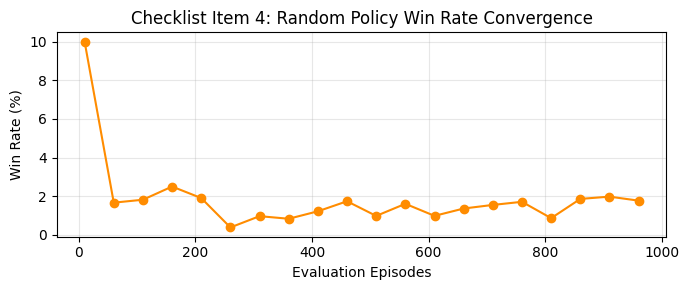

In [6]:
#Run random policy on FrozenLake and plot win rate
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env_lake = gym.make('FrozenLake-v1', is_slippery=False)
np.random.seed(42)

trial_counts = np.arange(10, 1001, 50)
win_rates = []

for count in trial_counts:
    wins = 0
    for _ in range(count):
        s, _ = env_lake.reset()
        while True:
            action = env_lake.action_space.sample()
            s, r, term, trunc, _ = env_lake.step(action)
            if term or trunc:
                if r == 1.0: wins += 1
                break
    win_rates.append(wins / count)

plt.figure(figsize=(7, 3))
plt.plot(trial_counts, np.array(win_rates) * 100, color='darkorange', marker='o')
plt.xlabel('Evaluation Episodes'); plt.ylabel('Win Rate (%)')
plt.title('Checklist Item 4: Random Policy Win Rate Convergence')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
